Sales Analysis for an E-commerce Business

## Objective

The goal of this project is to analyze e-commerce sales data and identify revenue trends, top-performing categories, regional performance, and seasonal sales patterns in order to generate useful business insights.

## Data Overview

This dataset contains 34,500 sales transactions and 17 columns, including product category, region, price, quantity, total amount, discount, and profit margin.

Initial exploration showed that the dataset contains no missing values, making it suitable for further analysis.

In [ ]:
import pandas as pd

# φόρτωση δεδομένων
df = pd.read_csv('ecommerce_sales_34500.csv')

# εμφάνιση πρώτων γραμμών
df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [ ]:
# βασικές πληροφορίες
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  object 
 1   customer_id         34500 non-null  object 
 2   product_id          34500 non-null  object 
 3   category            34500 non-null  object 
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  object 
 8   order_date          34500 non-null  object 
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  object 
 11  returned            34500 non-null  object 
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  cust

In [ ]:
df.describe()

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,4.814203,170.008494,6.152120,28.116505,43.474377
std,195.620477,0.069894,0.932270,1.242141,357.503014,2.389539,53.352947,14.980682
min,1.010000,0.000000,1.000000,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,13.000000,12931.800000,15.650000,1536.170000,69.000000


In [ ]:
# μετατροπή ημερομηνίας σε σωστό format
df['order_date'] = pd.to_datetime(df['order_date'])

# δημιουργία νέων στηλών
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['day'] = df['order_date'].dt.day

# έλεγχος
df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender,year,month,day
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female,2023,12,23
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male,2025,4,3
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male,2024,10,8
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female,2024,9,14
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male,2024,12,21


In [ ]:
# συνολικές πωλήσεις
total_sales = df['total_amount'].sum()
print("Total Sales:", total_sales)

Total Sales: 5865293.050000001


In [ ]:
category_sales = df.groupby('category')['total_amount'].sum().sort_values(ascending=False)
category_sales

,total_amount
category,
Electronics,3319206.50
Home,1077681.52
Sports,629825.54
Fashion,471545.80
Beauty,153019.38
Toys,132013.80
Grocery,82000.51


In [ ]:
monthly_sales = df.groupby('month')['total_amount'].sum()
monthly_sales

,total_amount
month,
1,442156.30
2,443352.17
3,487523.09
4,528620.69
5,513402.69
6,482931.66
7,502962.90
8,456421.70
9,461857.67


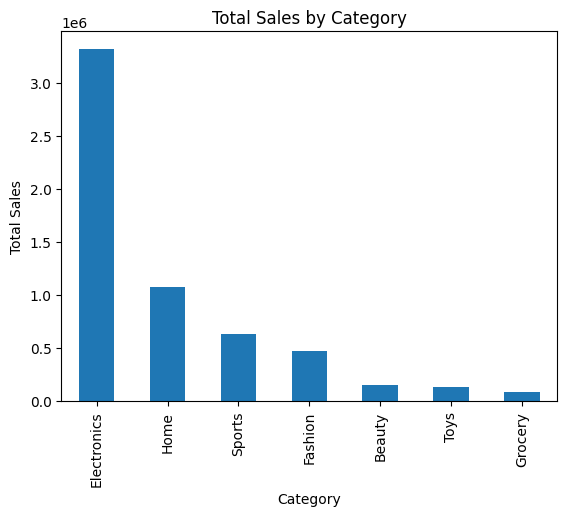

In [ ]:
import matplotlib.pyplot as plt

# category sales plot
category_sales.plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.show()

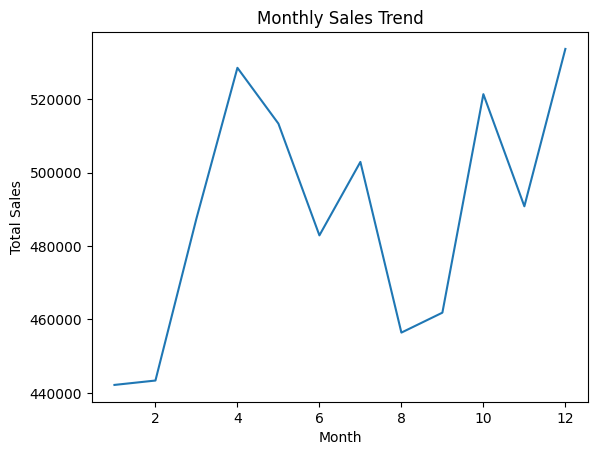

In [ ]:
monthly_sales.plot(kind='line')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.show()

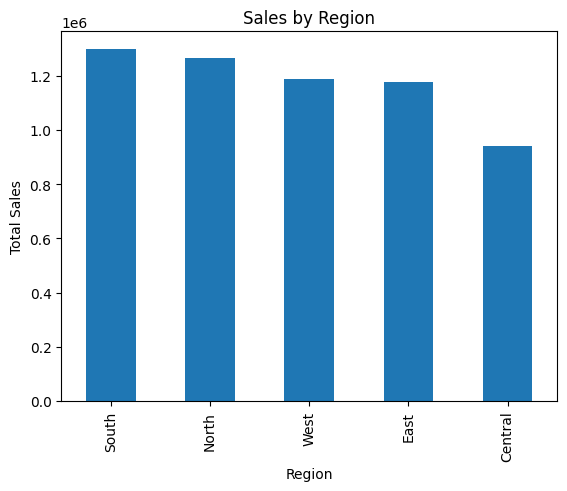

In [ ]:
region_sales = df.groupby('region')['total_amount'].sum().sort_values(ascending=False)

region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.show()

## Key Insights

### 1. Category Performance
The Electronics category significantly outperforms all other categories, contributing the largest share of total revenue. This indicates that the business is highly dependent on electronics as its primary revenue driver.

### 2. Regional Sales Distribution
Sales are strong across all regions, with the South region generating the highest revenue, followed closely by the North. This suggests a well-balanced market presence with slightly higher demand in the South.

### 3. Seasonal Trends
Sales peak during April and December, indicating possible seasonal patterns. These peaks may be linked to promotional periods, seasonal demand, or holiday-related consumer behavior.

### 4. Stable Revenue Flow
Despite seasonal peaks, sales remain relatively consistent throughout the year, showing that the business maintains steady performance across different months.

## Business Recommendations

### 1. Focus on High-Performing Category
The company should prioritize the Electronics category by increasing inventory, marketing investment, and promotional efforts, as it generates the majority of revenue.

### 2. Leverage Seasonal Peaks
Marketing campaigns and discounts should be intensified before April and December to maximize sales during peak demand periods.

### 3. Expand in Strong Regions
Since the South region shows the highest sales, the company could further expand operations, logistics, or targeted campaigns in that area to increase market share.

### 4. Explore Underperforming Categories
Lower-performing categories such as Grocery and Toys could be further analyzed to identify opportunities for improvement or repositioning.

## Conclusion

This project analyzed e-commerce sales data to identify the main drivers of business performance. The analysis showed that Electronics is the strongest category, the South region performs slightly better than the others, and April and December are the strongest sales months. These findings can support better planning, marketing decisions, and category management.